# osapiens Challenge Makeathon 2026 — Detecting Deforestation from Space

---

## Table of Contents

1. Data Download / Structure / Setup
2. Challenge: Detecting Deforestation from Space
3. Definition of Deforestation
4. Data Description & Visualisation
   - 4.1 Sentinel-2
   - 4.2 Sentinel-1
   - 4.3 AlphaEarth Foundations
5. Labels Description & Visualisation
   - 5.1 RADD Alert Labels
   - 5.2 GLAD-L Alert Labels
   - 5.3 GLAD-S2 Alert Labels
6. Submission
   - 6.1 Example: using `submission_utils.py`
7. Helpful Resources

## 1 — Data Download / Structure / Setup

> run `make download_data_from_s3` from your terminal to download data

After downloading, the dataset lives under `data/makeathon-challenge/` and is split into `train` and `test` sets across four top-level folders.

```
data/makeathon-challenge/
├── sentinel-1/
│   ├── train/{tile_id}__s1_rtc/{tile_id}__s1_rtc_{year}_{month}_{ascending|descending}.tif
│   └── test/  ...
├── sentinel-2/
│   ├── train/{tile_id}__s2_l2a/{tile_id}__s2_l2a_{year}_{month}.tif
│   └── test/  ...
├── aef-embeddings/
│   ├── train/{tile_id}_{year}.tiff
│   └── test/  ...
├── labels/train/
│   ├── gladl/   gladl_{tile_id}_alert{YY}.tif  +  gladl_{tile_id}_alertDate{YY}.tif
│   ├── glads2/  glads2_{tile_id}_alert.tif     +  glads2_{tile_id}_alertDate.tif
│   └── radd/    radd_{tile_id}_labels.tif
└── metadata/
    ├── train_tiles.geojson
    └── test_tiles.geojson
```

Each tile is identified by an ID of the form `{MGRS_grid}_{x}_{y}` (e.g. `18NWG_6_6`), encoding its position within a Military Grid Reference System tile. Sentinel-1 and Sentinel-2 are monthly time series; AlphaEarth embeddings are annual. Labels are only provided for the training set — the test set is used exclusively for leaderboard evaluation. Spatial coverage of all tiles is documented in the two GeoJSON files under `metadata/`.

**We want to emphasize that you are not required to use these specific data sources or labels in your solution.** You are free to incorporate any additional data sources or labels you find useful, as long as your final submission follows the required format and contains predictions only for the test set tiles. More on submission format in section 6.

## 2 — Challenge: Detecting Deforestation from Space

![deforestation](content/deforestation.png)
> The picture above shows a deforestation event in the Cerrado Region, Brazil captured by Sentinel-2 in September 2020.

As global deforestation continues, the EU Deforestation Regulation (EUDR) is driving demand for large-scale geospatial monitoring by requiring companies to verify that their supply chains are deforestation-free.

Satellite constellations monitor Earth at global scale using optical and radar sensors—but turning this data into reliable insights is difficult.

Satellite data is noisy, heterogeneous, and varies across sensors, regions, and environmental conditions.

As a result, deforestation detection systems often lack accuracy and generalization.

Building systems that can turn these imperfect signals into reliable, automated, and globally consistent evidence remains an open problem and the focus of this challenge.



## 3 — Definition of Deforestation

For this challenge, we focus exclusively on deforestation events occurring after 2020. Deforestation is defined as the permanent removal of tree cover, leading to a transition from forest to non-forest land. Accordingly, an event is only considered deforestation after 2020 if the area was forest in 2020.

## 4 — Data Description & Visualisation

In this challenge we have 3 data modalities (Sentinel-2, Sentinel-1, and AlphaEarth Foundations) and 3 weak-label sources (RADD, GLAD-L, and GLAD-S2). Each has different characteristics, strengths, and limitations. Understanding these is crucial for building effective models. In the sections below, we provide an overview of each data source, along with code snippets to load and visualize the data.

### 4.1 — Sentinel-2

Each pixel in the Sentinel-2 data contains 12 spectral bands, each capturing reflectance at different wavelengths. These bands provide complementary information about land cover, vegetation health, soil properties, and atmospheric conditions. Below is a summary of the Sentinel-2 bands included in the dataset:

| Band | Name / Type | Resolution (m/px) | Central Wavelength (nm) | Bandwidth (nm) | Description / Use |
|------|------------|-------------------|--------------------------|----------------|-------------------|
| B01 | Aerosol | 60 | 443 | 20 | Aerosol detection |
| B02 | Blue | 10 | 490 | 65 | Soil & vegetation discrimination, forest mapping, detects man-made features |
| B03 | Green | 10 | 560 | 35 | Water clarity contrast, vegetation reflectance, highlights oil |
| B04 | Red | 10 | 665 | 30 | Vegetation, soil, urban areas, strong reflection from dead foliage |
| B05 | Red Edge | 20 | 705 | 15 | Vegetation classification |
| B06 | Red Edge | 20 | 740 | 15 | Vegetation classification |
| B07 | Red Edge | 20 | 783 | 20 | Vegetation classification |
| B08 | NIR | 10 | 842 | 115 | Biomass, vegetation analysis, shoreline mapping |
| B8A | Narrow NIR | 20 | 865 | 20 | Vegetation classification |
| B09 | Water Vapour | 60 | 945 | 20 | Water vapour detection |
| B10 | Cirrus | 60 | 1375 | 30 | Cirrus cloud detection |
| B11 | SWIR 1 | 20 | 1610 | 90 | Moisture content, vegetation contrast, snow vs cloud differentiation |
| B12 | SWIR 2 | 20 | 2190 | 180 | Moisture content, vegetation contrast, snow vs cloud differentiation |

Source: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/

All bands are provided in a single multi-band `.tif` file and are upsampled to 10m resolution for consistency. The data is delivered in a local UTM projected CRS. Observations are not mosaicked and represent the single best cloud-free scene for a given month. When combining with other rasters (e.g. labels), ensure all files are reprojected to the same CRS to guarantee proper alignment.

In [1]:
import numpy as np
import rasterio

S2_PATH    = "makeathon-challenge/sentinel-2/train/18NWG_6_6__s2_l2a/18NWG_6_6__s2_l2a_2020_1.tif"
ALERT_PATH = "makeathon-challenge/labels/train/glads2/glads2_18NWG_6_6_alert.tif"

with rasterio.open(S2_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020 | Month: January")
    print(f"Number of bands : {src.count}")  # all 12 spectral bands present; we render only RGB (B4, B3, B2)
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020 | Month: January
Number of bands : 12
Dtype           : uint16
CRS             : EPSG:32618
Shape           : (1002, 1002)


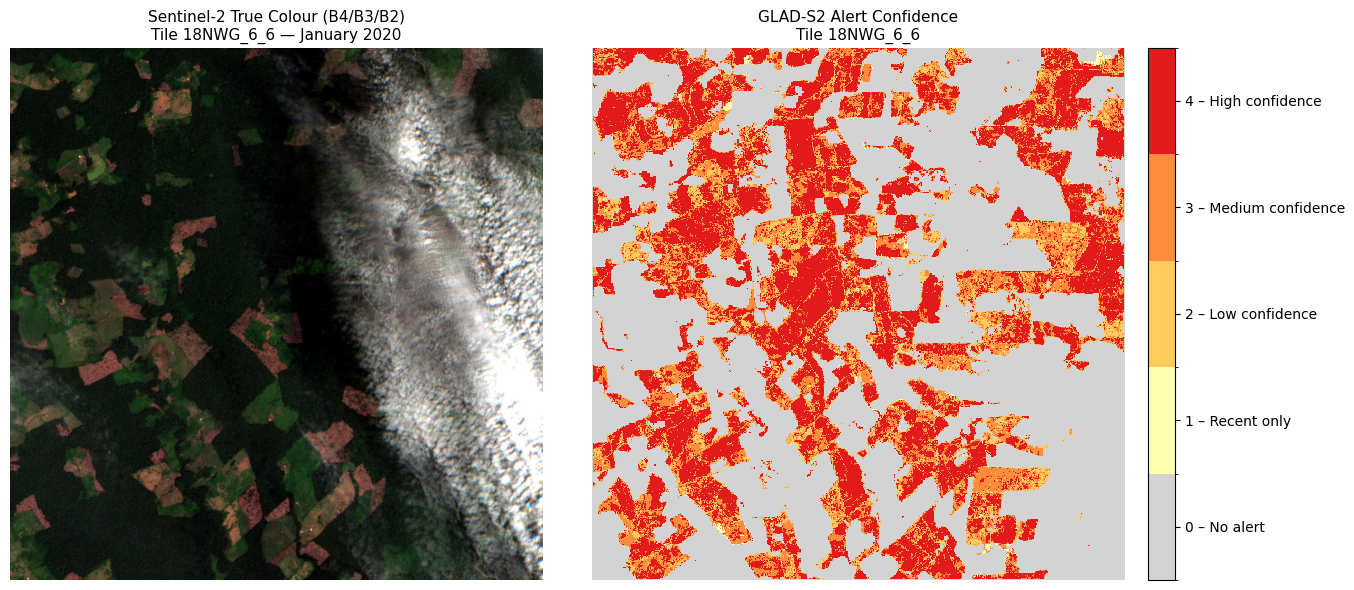

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from rasterio.warp import reproject, Resampling

# Load Sentinel-2 RGB bands: B4 = Red (index 4), B3 = Green (index 3), B2 = Blue (index 2)
with rasterio.open(S2_PATH) as src:
    red   = src.read(4).astype(np.float32)
    green = src.read(3).astype(np.float32)
    blue  = src.read(2).astype(np.float32)
    s2_transform = src.transform
    s2_crs       = src.crs
    s2_shape     = src.shape

def percentile_normalise(band, p_lo=2, p_hi=98):
    valid = band[band > 0]
    lo, hi = np.percentile(valid, [p_lo, p_hi])
    return np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)

rgb = np.stack(
    [percentile_normalise(red), percentile_normalise(green), percentile_normalise(blue)],
    axis=-1,
)

# Reproject GLAD-S2 alert (EPSG:4326) onto the Sentinel-2 grid (UTM)
with rasterio.open(ALERT_PATH) as src:
    alert_reproj = np.zeros(s2_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_reproj,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s2_transform,
        dst_crs=s2_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(rgb)
axes[0].set_title("Sentinel-2 True Colour (B4/B3/B2)\nTile 18NWG_6_6 — January 2020", fontsize=11)
axes[0].axis("off")

cmap = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

im = axes[1].imshow(alert_reproj, cmap=cmap, norm=norm, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


### 4.2 — Sentinel-1

Sentinel-1 is a radar satellite that provides all-weather (can penetrate clouds), day-and-night imaging capabilities. It captures the Earth's surface using microwave signals, which are reflected back to the satellite. The dataset includes 1 radar backscatter channel with VV polarisation. You can read more about Sentinel-1 Mission here: https://sentiwiki.copernicus.eu/web/s1-mission

Sentinel-1 data is available at multiple processing levels. For this challenge, we provide the highest standard: **Radiometrically Terrain Corrected (RTC)** product. Measurements have been preprocessed to correct for terrain-induced distortions and radiometric effects, making them ready for direct analysis and modeling.

The data is delivered in a local UTM projected coordinate reference system (CRS), aligned with Sentinel-2. When combining these data with other rasters (e.g., labels), ensure that all datasets are reprojected to the same CRS to guarantee proper spatial alignment.


In [3]:
S1_PATH = "makeathon-challenge/sentinel-1/train/18NWG_6_6__s1_rtc/18NWG_6_6__s1_rtc_2020_10_ascending.tif"

with rasterio.open(S1_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020 | Month: October | Orbit: ascending")
    print(f"Number of bands : {src.count}")  # 1 band — VV polarisation (linear scale)
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020 | Month: October | Orbit: ascending
Number of bands : 1
Dtype           : float32
CRS             : EPSG:32618
Shape           : (334, 335)


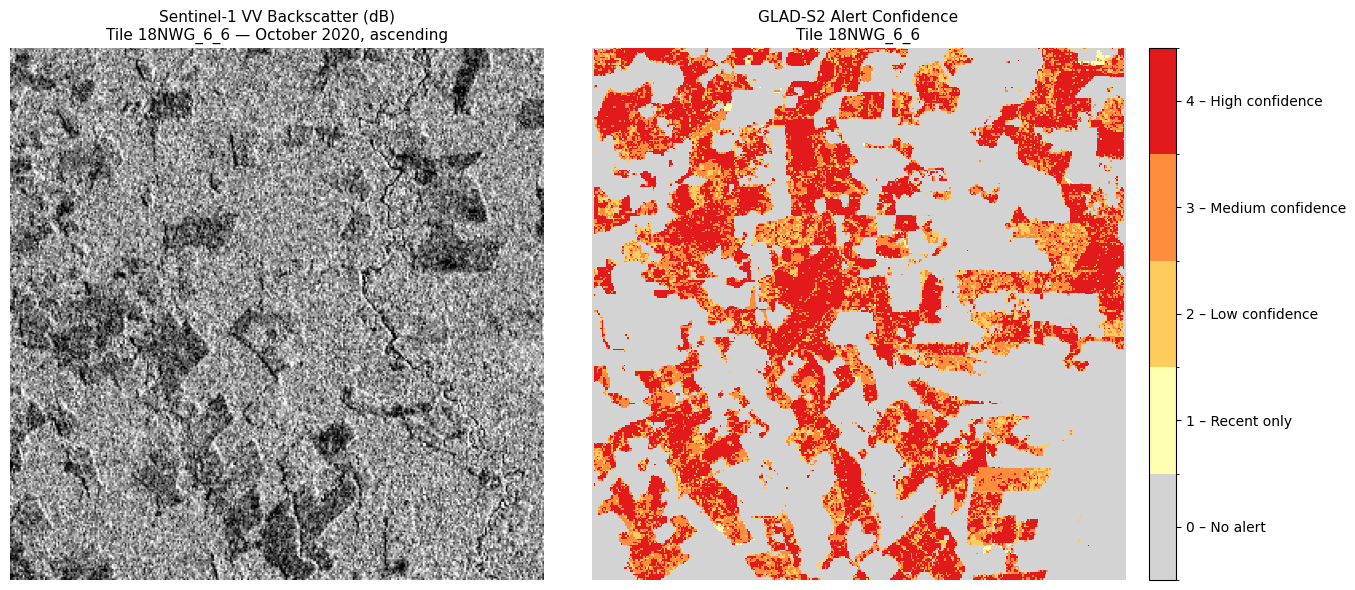

In [4]:
with rasterio.open(S1_PATH) as src:
    backscatter  = src.read(1).astype(np.float32)
    s1_transform = src.transform
    s1_crs       = src.crs
    s1_shape     = src.shape

# Convert linear backscatter to dB and normalise for display
db = np.where(backscatter > 0, 10 * np.log10(backscatter), np.nan)
valid = db[np.isfinite(db)]
lo, hi = np.percentile(valid, [2, 98])
s1_display = np.nan_to_num(np.clip((db - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

# Reproject GLAD-S2 alert onto the S1 grid
with rasterio.open(ALERT_PATH) as src:
    alert_s1 = np.zeros(s1_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_s1,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=s1_transform,
        dst_crs=s1_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(s1_display, cmap="gray")
axes[0].set_title("Sentinel-1 VV Backscatter (dB)\nTile 18NWG_6_6 — October 2020, ascending", fontsize=11)
axes[0].axis("off")

cmap_alert = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm_alert = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_alert.N)

im = axes[1].imshow(alert_s1, cmap=cmap_alert, norm=norm_alert, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


### 4.3 — AlphaEarth Foundations (EPSG:4326)

AlphaEarth Foundations is a global dataset of pre-trained embeddings derived from multiple satellite data sources, including Sentinel-2 and Sentinel-1. These embeddings are designed to capture rich spatio-temporal patterns in the data, providing a powerful representation for downstream tasks like deforestation detection.

The dataset is organized into tiles that cover the same spatial extent as the Sentinel-2 and Sentinel-1 data, but is delivered in a geodetic coordinate reference system (CRS) of EPSG:4326 (WGS-84). This means that the pixel coordinates are defined in terms of latitude and longitude, rather than projected coordinates like UTM. When using the AlphaEarth Foundations embeddings in conjunction with the Sentinel-2 and Sentinel-1 data, it is crucial to reproject the embeddings to the same CRS (local UTM) to ensure proper spatial alignment before modeling. This can be done using geospatial libraries such as `rasterio` or `GDAL`, which allow for efficient reprojection of raster data while preserving the integrity of the embeddings.


Paper: https://arxiv.org/abs/2507.22291


In [5]:
AEF_PATH = "makeathon-challenge/aef-embeddings/train/18NWG_6_6_2020.tiff"

with rasterio.open(AEF_PATH) as src:
    print("Tile: 18NWG_6_6 | Year: 2020")
    print(f"Number of bands : {src.count}")  # 64 embedding dimensions; we display 3 randomly chosen bands as RGB
    print(f"Dtype           : {src.dtypes[0]}")
    print(f"CRS             : {src.crs}")
    print(f"Shape           : {src.shape}")


Tile: 18NWG_6_6 | Year: 2020
Number of bands : 64
Dtype           : float32
CRS             : EPSG:4326
Shape           : (1004, 998)


Randomly selected bands (1-indexed): [6, 42, 49]


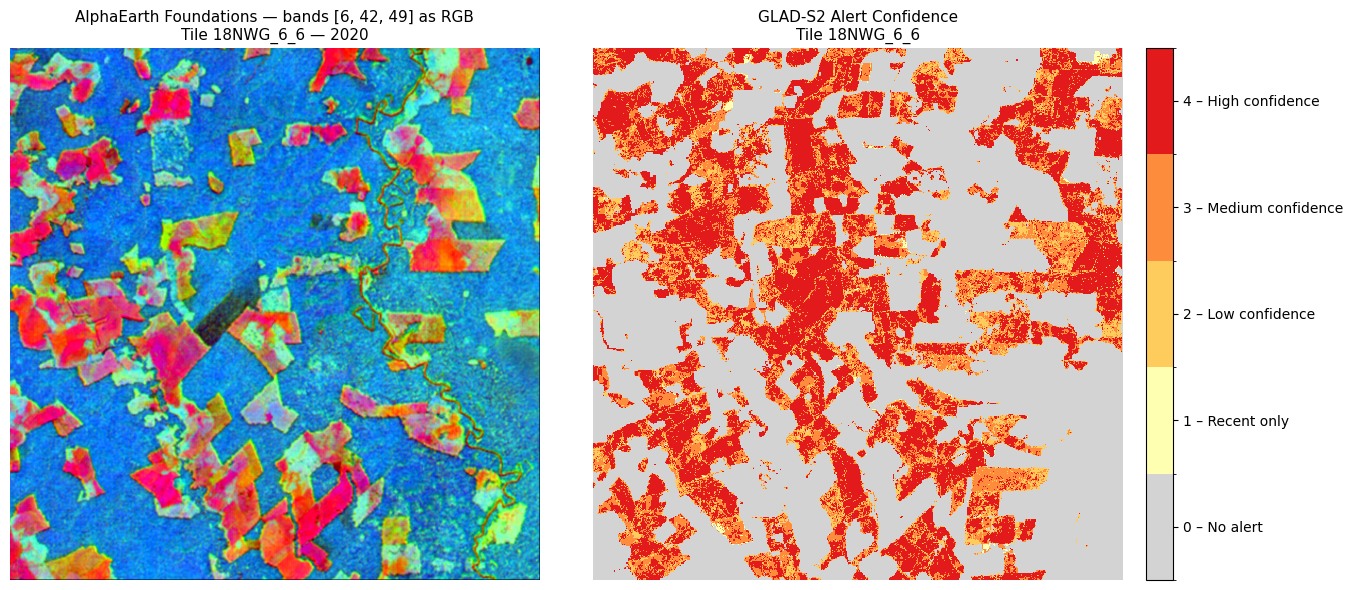

In [6]:
rng = np.random.default_rng(seed=42)
chosen = sorted(rng.choice(64, size=3, replace=False).tolist())
print(f"Randomly selected bands (1-indexed): {[b + 1 for b in chosen]}")

with rasterio.open(AEF_PATH) as src:
    aef_data     = src.read([b + 1 for b in chosen]).astype(np.float32)
    aef_transform = src.transform
    aef_crs       = src.crs
    aef_shape     = src.shape

def normalise_nan(band, p_lo=2, p_hi=98):
    valid = band[np.isfinite(band)]
    lo, hi = np.percentile(valid, [p_lo, p_hi])
    return np.nan_to_num(np.clip((band - lo) / (hi - lo + 1e-6), 0, 1), nan=0.0)

aef_rgb = np.stack([normalise_nan(aef_data[i]) for i in range(3)], axis=-1)

# Both AEF and GLAD-S2 are in EPSG:4326 — resample alert onto the AEF grid
with rasterio.open(ALERT_PATH) as src:
    alert_aef = np.zeros(aef_shape, dtype=np.uint8)
    reproject(
        source=src.read(1),
        destination=alert_aef,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=aef_transform,
        dst_crs=aef_crs,
        resampling=Resampling.nearest,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(aef_rgb)
axes[0].set_title(
    f"AlphaEarth Foundations — bands {[b + 1 for b in chosen]} as RGB\nTile 18NWG_6_6 — 2020",
    fontsize=11,
)
axes[0].axis("off")

cmap_alert = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm_alert = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap_alert.N)

im = axes[1].imshow(alert_aef, cmap=cmap_alert, norm=norm_alert, interpolation="nearest")
axes[1].set_title("GLAD-S2 Alert Confidence\nTile 18NWG_6_6", fontsize=11)
axes[1].axis("off")

cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1, 2, 3, 4])
cbar.ax.set_yticklabels(
    ["0 – No alert", "1 – Recent only", "2 – Low confidence", "3 – Medium confidence", "4 – High confidence"]
)

plt.tight_layout()
plt.show()


## 5 — Labels Description and Encodings

The challenge includes three sources of weak\* labels for deforestation: RADD, GLAD-L, and GLAD-S2. Each label source has different characteristics, strengths, and limitations. Below we provide an overview of each label type, along with code snippets to load and visualize the labels.

\*By weak labels, we mean that these are not perfect ground truth (predictions in fact), but rather noisy indicators of deforestation events. They can be used for training and evaluation, but it's important to understand their limitations and potential biases when interpreting model performance.


### 5.1 — RADD (Radar for Detecting Deforestation) Alert Labels

RADD is a state-of-the-art deforestation detection system that uses Sentinel-1 radar data to identify deforestation events. RADD generates binary alert masks indicating areas of potential deforestation, along with confidence scores for each alert.

We provide the alerts in it's rawest form meaning there was no post-processing was done from our side.

Here is everything you should know to understand the RADD labels:

Source files:

- one raw tile TIFF per dataset tile

Encoding:

- one integer encodes both confidence and alert date
- leading digit:
    - `2` = low confidence
    - `3` = high confidence
- remaining digits:
    - number of days since `2014-12-31`
- `0` = no alert

Examples:

- `20001` = low-confidence alert on `2015-01-01`
- `30055` = high-confidence alert on `2015-02-24`
- `21847` = low-confidence alert on `2020-01-21`


### 5.2 — GLAD-L (Global Land Analysis & Discovery — Landsat) Alert Labels

GLAD-L is a deforestation alert system that uses Landsat optical data to identify potential deforestation events. Similar to RADD, GLAD-L generates binary alert masks and alert-date rasters, but with different confidence encoding and known limitations.

Here is everything you should know to understand the GLAD-L labels:

Source files:

- `alertYY.tif`
- `alertDateYY.tif`

Examples:

- `alert24.tif`
- `alertDate24.tif`

Encoding:

- `alertYY` is a raw yearly alert raster, usually `uint8`
    - `0` = no loss
    - `2` = probable loss
    - `3` = confirmed loss
- `alertDateYY` is a raw yearly alert-date raster, usually `uint16`
    - value = day-of-year within year `20YY`
    - `0` = no alert

### 5.3 — GLAD-S2 (Global Land Analysis & Discovery — Sentinel-2) Alert Labels

GLAD-S2 is a deforestation alert system that uses Sentinel-2 optical data to identify potential deforestation events. It provides similar outputs to GLAD-L, but with different confidence encoding and known limitations.

Here is everything you should know to understand the GLAD-S2 labels:

Source files:

- `alert.tif`
- `alertDate.tif`

Encoding:

- `alert` is a raw confidence raster, usually `uint8`
    - `0` = no loss
    - `1` = loss detected only in the most recent observation
    - `2` = low confidence loss
    - `3` = medium confidence loss
    - `4` = high confidence loss
- `alertDate` is a raw day-offset raster, usually `uint16`
    - value = number of days since `2019-01-01`
    - `0` = no alert

*Note*: Compared to GLAD-L, GLAD-S2 includes all years in a single raster that is why YY is not included in the file names.

## 6 — Submission


### 6.1 — Example: using `submission_utils.py`

> Walk-through of how to convert a binary prediction raster into the submittable format using the provided utility script.

## 7 — Helpful Resources

- QGIS for desktop visualization of the rasters (.tif files) or polygons (.geojson files)
- Python libraries: Geopandas (vector data), Rasterio (raster data)

In [26]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

def get_aligned_data(source_path, template_meta):
    """
    Reprojects any satellite or label file to match a template's 
    grid, CRS, and resolution.
    """
    with rasterio.open(source_path) as src:
        # Create an empty array with the template's shape (height, width)
        aligned_array = np.zeros((template_meta['height'], template_meta['width']), 
                                 dtype=src.dtypes[0])
        
        reproject(
            source=src.read(1),
            destination=aligned_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=template_meta['transform'],
            dst_crs=template_meta['crs'],
            resampling=Resampling.nearest, # Best for labels/categories
        )
        return aligned_array

In [27]:
# ============================================================
#  PATCH DATASET BUILDER — All Fixes Including Median Composite
# ============================================================
import numpy as np
import rasterio
import glob
import os
from rasterio.warp import reproject, Resampling

TRAIN_S2_DIR = "makeathon-challenge/sentinel-2/train"
train_tiles  = sorted([f.split("__")[0] for f in os.listdir(TRAIN_S2_DIR) if f.endswith("__s2_l2a")])

PATCH_SIZE = 256
STRIDE     = 128

# ✅ FIX: Train on ALL year pairs, not just 2020
YEAR_PAIRS = [
    ("2020", "2021"), ("2020", "2022"), ("2020", "2023"), ("2020", "2024"),
    ("2021", "2023"), ("2021", "2024"), ("2022", "2024"),
]

patches_X, patches_y = [], []


# ─────────────────────────────────────────────────────────────
# ✅ FIX 6: Temporal Median Composite
#    Instead of reading ONE scene per year, reads ALL scenes
#    for that year and returns the pixel-wise median.
#    Clouds = outliers → automatically removed by the median.
# ─────────────────────────────────────────────────────────────
def read_s2_median_composite(tif_files, meta):
    """
    Given a list of S2 .tif files for one year,
    returns (12, H, W) float32 median composite, scaled to [0,1].
    """
    all_scenes = []
    for path in tif_files:
        try:
            out = np.zeros((12, meta['height'], meta['width']), dtype=np.float32)
            with rasterio.open(path) as src:
                for i in range(12):
                    reproject(
                        source=src.read(i + 1),
                        destination=out[i],
                        src_transform=src.transform, src_crs=src.crs,
                        dst_transform=meta['transform'], dst_crs=meta['crs'],
                        resampling=Resampling.bilinear
                    )
            all_scenes.append(out)
        except Exception as e:
            print(f"      ⚠️  Skipping {os.path.basename(path)}: {e}")
            continue

    if len(all_scenes) == 0:
        return np.zeros((12, meta['height'], meta['width']), dtype=np.float32)

    # Stack → (N_scenes, 12, H, W), then pixel-wise median across scenes
    stacked   = np.stack(all_scenes, axis=0)          # (N, 12, H, W)
    composite = np.median(stacked, axis=0)             # (12, H, W)
    return (composite / 10000.0).clip(0, 1).astype(np.float32)


def get_aligned_data(source_path, template_meta):
    """Reprojects any raster file to match the template grid."""
    with rasterio.open(source_path) as src:
        aligned = np.zeros(
            (template_meta['height'], template_meta['width']),
            dtype=src.dtypes[0]
        )
        reproject(
            source=src.read(1),
            destination=aligned,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=template_meta['transform'], dst_crs=template_meta['crs'],
            resampling=Resampling.nearest
        )
    return aligned


def extractpatches(image, mask, size, stride):
    px, py = [], []
    H, W = image.shape[1], image.shape[2]
    for r in range(0, H - size + 1, stride):      # ✅ H - size + 1, not H - size
        for c in range(0, W - size + 1, stride):  # ✅ same
            pimg  = image[:, r:r+size, c:c+size]
            pmask = mask[r:r+size, c:c+size]
            # ✅ Hard shape check — skip any patch not exactly size×size
            if pimg.shape[1] != size or pimg.shape[2] != size:
                continue
            if np.sum(pmask) > 5:
                px.append(pimg)
                py.append(pmask)
    return px, py

print("Building patch dataset...")
total_def_patches = 0

for tile_id in train_tiles:
    s2_folder = f"makeathon-challenge/sentinel-2/train/{tile_id}__s2_l2a"
    s1_folder = f"makeathon-challenge/sentinel-1/train/{tile_id}__s1_rtc"

    all_tifs = sorted(glob.glob(s2_folder + "/*.tif"))
    if not all_tifs:
        continue

    try:
        # Use the first available scene just to read the grid/CRS
        with rasterio.open(all_tifs[0]) as src:
            meta = src.meta

        # ── Load labels ONCE per tile ──────────────────────────────
        radd   = get_aligned_data(
            f"makeathon-challenge/labels/train/radd/radd_{tile_id}_labels.tif", meta)
        gladl  = get_aligned_data(
            f"makeathon-challenge/labels/train/gladl/gladl_{tile_id}_alert24.tif", meta)
        gp     = f"makeathon-challenge/labels/train/glads2/glads2_{tile_id}_alert.tif"
        glads2 = get_aligned_data(gp, meta) if os.path.exists(gp) else np.zeros_like(radd)

        raw_label = ((radd >= 20000) | (glads2 >= 2) | (gladl >= 2)).astype(np.uint8)

    except Exception as e:
        print(f"  ⚠️  {tile_id} label load failed: {e}")
        continue

    # ── Loop over year pairs ───────────────────────────────────────
    for yr_bef, yr_aft in YEAR_PAIRS:

        bef_files = sorted(glob.glob(s2_folder + f"/*{yr_bef}*.tif"))
        aft_files = sorted(glob.glob(s2_folder + f"/*{yr_aft}*.tif"))
        s1_bef    = sorted(glob.glob(s1_folder + f"/*{yr_bef}*.tif"))
        s1_aft    = sorted(glob.glob(s1_folder + f"/*{yr_aft}*.tif"))

        if not bef_files or not aft_files or not s1_bef or not s1_aft:
            continue   # this year pair doesn't exist for this tile

        try:
            # ✅ FIX 6: use median composite instead of single scene
            bef = read_s2_median_composite(bef_files, meta)   # (12, H, W)
            aft = read_s2_median_composite(aft_files, meta)   # (12, H, W)

            # ✅ FIX: correct band indices for S2 (0-indexed, 12 bands)
            #   band 3 = Red (B4),  band 7 = NIR (B8),  band 10 = SWIR-1 (B11)
            ndvi_bef = (bef[7] - bef[3]) / (bef[7] + bef[3] + 1e-6)
            ndvi_aft = (aft[7] - aft[3]) / (aft[7] + aft[3] + 1e-6)

            delta_ndvi = (ndvi_bef - ndvi_aft)[np.newaxis]    # (1, H, W)
            delta_swir = (aft[10]  - bef[10]) [np.newaxis]    # (1, H, W)  ✅ fixed name

            # ── Forest filter ──────────────────────────────────────
            was_forest = (ndvi_bef > 0.35)
            lost_green = (ndvi_bef - ndvi_aft) > 0.15
            mask = np.where(raw_label & was_forest & lost_green, 1, 0).astype(np.uint8)

            # ── 26-channel image (12 before + 12 after + Δndvi + Δswir) ─
            image = np.concatenate(
                [bef, aft, delta_ndvi, delta_swir], axis=0   # (26, H, W)
            )

            px, py = extract_patches(image, mask, PATCH_SIZE, STRIDE)
            patches_X.extend(px)
            patches_y.extend(py)
            total_def_patches += len(px)

        except Exception as e:
            print(f"  ⚠️  {tile_id}  {yr_bef}→{yr_aft}: {e}")

print(f"\nTotal deforestation patches: {total_def_patches}")
print(f"Dataset size: {len(patches_X)} patches of shape (26, {PATCH_SIZE}, {PATCH_SIZE})")

Building patch dataset...

Total deforestation patches: 3121
Dataset size: 3121 patches of shape (26, 256, 256)


In [35]:
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import torch
import numpy as np

class ForestDataset(Dataset):
    def __init__(self, images, masks, augment=True):
        self.images = images
        self.masks = masks
        self.augment = augment
        self.aug = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Transpose(p=0.3),
            A.RandomBrightnessContrast(
                brightness_limit=0.2, contrast_limit=0.2, p=0.4
            ),
            A.GaussNoise(noise_scale_factor=0.05, p=0.3),
            A.CoarseDropout(
                num_holes_range=(8, 12),
                hole_height_range=(16, 32),
                hole_width_range=(16, 32),
                fill=0, p=0.3
            ),
            A.GridDistortion(p=0.2),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):                         # ← line 22
        img  = self.images[idx].copy()   # (26, H, W)  # ← line 23 — must be indented!
        mask = self.masks[idx].copy()    # (H, W)

        if self.augment:
            img_hwc = img.transpose(1, 2, 0)  # albumentations needs HWC
            result  = self.aug(image=img_hwc, mask=mask)
            img     = result["image"].transpose(2, 0, 1)  # back to CHW
            mask    = result["mask"]

        return (
            torch.tensor(img,  dtype=torch.float32),
            torch.tensor(mask, dtype=torch.long),
        )


# ── DataLoader setup ────────────────────────────────────────
split      = int(0.85 * len(patches_X))
train_ds   = ForestDataset(patches_X[:split], patches_y[:split], augment=True)
val_ds     = ForestDataset(patches_X[split:], patches_y[split:], augment=False)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train {len(train_ds)} patches  |  Val {len(val_ds)} patches")
print(f"Batch size 4  |  Train batches {len(train_loader)}  |  Val batches {len(val_loader)}")

Train 2652 patches  |  Val 469 patches
Batch size 4  |  Train batches 663  |  Val batches 118


In [36]:
import segmentation_models_pytorch as smp
import torch
import torch.nn.functional as F
import torch.nn as nn, torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Attention U-Net — best architecture for satellite segmentation
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",   # or "ssl" for remote sensing pretrained
    in_channels=6,                # your actual channel count
    classes=1,
    activation=None,
)
model = model.to(device)

# Hybrid Loss: Dice + Focal — best for class imbalance in satellite imagery
class FocalDiceLoss(torch.nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, dice_weight=0.5):
        super().__init__()
        self.alpha = alpha        # weight for deforested class
        self.gamma = gamma        # focus on hard examples
        self.dice_weight = dice_weight

    def focal_loss(self, pred, target):
        bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

    def dice_loss(self, pred, target, smooth=1.0):
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum()
        return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    def forward(self, pred, target):
        return self.focal_loss(pred, target) + self.dice_weight * self.dice_loss(pred, target)

In [ ]:
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import numpy as np

# ── CONFIG ────────────────────────────────────────────────────
IN_CHANNELS = 26   # 12 S2-before + 12 S2-after + delta_NDVI + delta_SWIR
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── MODEL: Attention U-Net with ResNet34 encoder ─────────────
model = smp.Unet(
    encoder_name    = "resnet34",
    encoder_weights = None,          # no ImageNet pretrain — our input isn't RGB
    in_channels     = IN_CHANNELS,   # ✅ must match your patches
    classes         = 1,
    activation      = None,
    decoder_attention_type = "scse", # squeeze-and-excitation attention
).to(device)

print(f"Model input channels: {IN_CHANNELS}")
print(f"Encoder first conv weight: {model.encoder.conv1.weight.shape}")  # should show [64, 26, 7, 7]

# ── LOSS: combined Dice + BCE (handles class imbalance well) ──
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([8.0]).to(device))

    def forward(self, logits, targets):
        targets_f = targets.float()
        bce_loss  = self.bce(logits.squeeze(1), targets_f)

        probs  = torch.sigmoid(logits.squeeze(1))
        inter  = (probs * targets_f).sum(dim=(1,2))
        union  = probs.sum(dim=(1,2)) + targets_f.sum(dim=(1,2))
        dice   = 1 - (2 * inter + self.smooth) / (union + self.smooth)
        return bce_loss + dice.mean()

criterion = DiceBCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr        = 3e-4,
    steps_per_epoch = len(train_loader),
    epochs        = 40,
    pct_start     = 0.1,
)

# ── TRAINING LOOP ─────────────────────────────────────────────
EPOCHS    = 40
best_iou  = 0
best_path = "best_attention_unet.pth"

for epoch in range(EPOCHS):
    # ---- TRAIN ----
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    # ---- VALIDATE ----
    model.eval()
    ious = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds   = torch.sigmoid(model(imgs)).squeeze(1)
            pred_bin = (preds > 0.40).long()
            inter = (pred_bin * masks).sum().item()
            union = (pred_bin + masks).clamp(0, 1).sum().item()
            if union > 0:
                ious.append(inter / union)

    val_iou = np.mean(ious) if ious else 0
    flag    = ""
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), best_path)
        flag = "  ✅ BEST"

    if (epoch + 1) % 5 == 0 or flag:
        print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
              f"Loss: {train_loss/len(train_loader):.4f} | "
              f"Val IoU: {val_iou:.4f}{flag}")

print(f"\n🏆 Best Val IoU: {best_iou:.4f}")
model.load_state_dict(torch.load(best_path, map_location=device))
print("✅ Attention U-Net ready!")

Using device: cuda
Model input channels: 26
Encoder first conv weight: torch.Size([64, 26, 7, 7])
Epoch  1/40 | Loss: 1.6289 | Val IoU: 0.3748  ✅ BEST


In [ ]:
from scipy.ndimage import binary_closing, binary_opening
from submission_utils import raster_to_geojson
import geopandas as gpd
import pandas as pd

TEST_S2_DIR    = "makeathon-challenge/sentinel-2/test"
SUBMISSION_DIR = "submission"
for f in glob.glob(SUBMISSION_DIR + "/pred_*.geojson"):
    os.remove(f)

test_tiles = sorted([f.split("__")[0] for f in os.listdir(TEST_S2_DIR) if f.endswith("__s2_l2a")])
model.eval()

def align_band(path, band_idx, meta):
    with rasterio.open(path) as src:
        out = np.zeros((meta['height'], meta['width']), dtype=np.float32)
        reproject(source=src.read(band_idx), destination=out,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=meta['transform'], dst_crs=meta['crs'],
            resampling=Resampling.bilinear)
    return out / 10000.0

for tile_id in test_tiles:
    print(f"Inferring {tile_id}...")
    s2_folder = f"makeathon-challenge/sentinel-2/test/{tile_id}__s2_l2a"
    bef_files = sorted(glob.glob(s2_folder + "/*_2020_*.tif") or glob.glob(s2_folder + "/*_2021_*.tif"))
    aft_files = sorted(glob.glob(s2_folder + "/*_2024_*.tif"))
    if not bef_files or not aft_files:
        print("  Skipping"); continue

    try:
        with rasterio.open(bef_files[0]) as src:
            meta = src.meta

        bef = read_s2_12bands(bef_files[0], meta)
        aft = read_s2_12bands(aft_files[0], meta)

        ndvi_bef   = (bef[7] - bef[3]) / (bef[7] + bef[3] + 1e-6)
        ndvi_aft   = (aft[7] - aft[3]) / (aft[7] + aft[3] + 1e-6)
        delta_ndvi = (ndvi_bef - ndvi_aft)[np.newaxis]
        delta_swir = (aft[10] - bef[10])[np.newaxis]

        image = np.concatenate([bef, aft, delta_ndvi, delta_swir], axis=0)  # (26,H,W)

        _, H, W = image.shape
        prob_map  = np.zeros((H, W), dtype=np.float32)
        count_map = np.zeros((H, W), dtype=np.float32)

        # Sliding window with test-time augmentation (TTA)
        with torch.no_grad():
            for r in range(0, max(1, H - PATCH_SIZE + 1), STRIDE):
                for c in range(0, max(1, W - PATCH_SIZE + 1), STRIDE):
                    patch = image[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE]
                    if patch.shape[1] < PATCH_SIZE or patch.shape[2] < PATCH_SIZE:
                        continue
                    t = torch.tensor(patch[None], dtype=torch.float32).to(device)

                    # TTA: average original + horizontal flip
                    p1 = torch.sigmoid(model(t)).squeeze().cpu().numpy()
                    p2 = torch.sigmoid(model(torch.flip(t, [3]))).squeeze().cpu().numpy()
                    p2 = np.fliplr(p2)
                    prob = (p1 + p2) / 2.0

                    prob_map[r:r+PATCH_SIZE, c:c+PATCH_SIZE]  += prob
                    count_map[r:r+PATCH_SIZE, c:c+PATCH_SIZE] += 1

        prob_map /= np.where(count_map == 0, 1, count_map)

        # Clean shape — small closing only, no dilation
        raw_pred = (prob_map >= 0.35).astype(np.uint8)
        closed   = binary_closing(raw_pred, structure=np.ones((3,3))).astype(np.uint8)
        final    = binary_opening(closed,   structure=np.ones((3,3))).astype(np.uint8)

        if np.sum(final) == 0:
            print("  No predictions"); continue

        temp_tif = f"{SUBMISSION_DIR}/temp_{tile_id}.tif"
        meta.update(dtype="uint8", nodata=0, count=1)
        with rasterio.open(temp_tif, 'w', **meta) as dst:
            dst.write(final, 1)

        try:
            out_json = f"{SUBMISSION_DIR}/pred_{tile_id}.geojson"
            raster_to_geojson(temp_tif, output_path=out_json, min_area_ha=0.5)

            # ✅ Remove blobs > 200ha immediately
            gdf = gpd.read_file(out_json)
            gdf = gdf[gdf.geometry.apply(
                lambda g: g.area * (111320**2) * np.cos(np.radians(g.centroid.y)) / 10000
            ) < 200]
            if len(gdf) > 0:
                gdf.to_file(out_json, driver="GeoJSON")
                print(f"  ✅ {len(gdf)} polygons")
            else:
                os.remove(out_json)
                print("  All blobs removed, no valid polygons")
        except ValueError:
            print("  All polygons < 0.5ha")

        if os.path.exists(temp_tif):
            os.remove(temp_tif)

    except Exception as e:
        print(f"  ⚠️ {tile_id}: {e}")

print("\n🎉 INFERENCE DONE!")

In [ ]:
from shapely import simplify
import pandas as pd, geopandas as gpd, os

SUBMISSION_DIR = "submission"
files = [os.path.join(SUBMISSION_DIR, f) for f in os.listdir(SUBMISSION_DIR)
         if f.startswith("pred_") and f.endswith(".geojson")]

gdfs = [gpd.read_file(f) for f in files]
merged = pd.concat(gdfs, ignore_index=True)

# ✅ Simplify jagged boundaries → tighter IoU
merged['geometry'] = merged['geometry'].apply(
    lambda g: simplify(g, tolerance=0.00005, preserve_topology=True)
)

if 'time_step' in merged.columns:
    merged['time_step'] = None

merged.to_file("submission/final_makeathon_submission.geojson", driver="GeoJSON")
print(f"✅ Final submission: {len(merged)} polygons")

In [ ]:
# ============================================================
# BONUS: DEFORESTATION TIMING ESTIMATION
# Determines the approximate year/month of each deforestation
# pixel and outputs it as a date raster alongside the binary mask.
# ============================================================

import numpy as np
import rasterio
import glob
import os
import torch
import geopandas as gpd
import pandas as pd
from datetime import date, timedelta
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from scipy.ndimage import binary_closing, binary_opening
from submissionutils import raster_to_geojson

# ── CONFIG ──────────────────────────────────────────────────
TEST_S2_DIR  = "makeathon-challenge/sentinel-2/test"
SUBMISSION_DIR = "submission"
os.makedirs(SUBMISSION_DIR, exist_ok=True)
RADD_EPOCH   = date(2014, 12, 31)   # RADD days since
GLADS2_EPOCH = date(2019, 1, 1)     # GLAD-S2 days since
THRESHOLD    = 0.40                  # same as your inference cell
# ────────────────────────────────────────────────────────────

def align_band(path, band_idx, meta):
    with rasterio.open(path) as src:
        out = np.zeros((meta['height'], meta['width']), dtype=np.float32)
        reproject(source=src.read(band_idx), destination=out,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=meta['transform'], dst_crs=meta['crs'],
                  resampling=Resampling.bilinear)
    return out / 10000.0

def load_date_raster(path, meta, resampling=Resampling.nearest):
    """Load any raster and reproject to meta grid, return uint16 array."""
    if not os.path.exists(path):
        return np.zeros((meta['height'], meta['width']), dtype=np.uint16)
    with rasterio.open(path) as src:
        out = np.zeros((meta['height'], meta['width']), dtype=np.float32)
        reproject(source=src.read(1).astype(np.float32),
                  destination=out,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=meta['transform'], dst_crs=meta['crs'],
                  resampling=resampling)
    return out.astype(np.uint16)

def radd_date_to_year(radd_date_val):
    """
    RADD date value = days since 2014-12-31.
    Returns approximate year (float) or 0 if no alert.
    """
    if radd_date_val == 0:
        return 0
    d = RADD_EPOCH + timedelta(days=int(radd_date_val))
    return d.year + d.timetuple().tm_yday / 365.0

def glads2_date_to_year(glads2_date_val):
    """
    GLAD-S2 date value = days since 2019-01-01.
    Returns approximate year (float) or 0 if no alert.
    """
    if glads2_date_val == 0:
        return 0
    d = GLADS2_EPOCH + timedelta(days=int(glads2_date_val))
    return d.year + d.timetuple().tm_yday / 365.0

def estimate_timing_raster(binary_mask, radd_date_arr, glads2_date_arr, gladl_date_arr):
    """
    For each deforested pixel, fuse multiple date sources into a
    single estimated year. Returns float32 array (0 = no deforestation).
    Strategy:
      - Convert each source to fractional year
      - Take the EARLIEST non-zero date (first detection = closest to truth)
      - Fall back to NDVI-change-based year-window if no date available
    """
    H, W = binary_mask.shape
    timing = np.zeros((H, W), dtype=np.float32)

    for r in range(H):
        for c in range(W):
            if binary_mask[r, c] == 0:
                continue
            candidates = []

            # RADD
            rv = radd_date_arr[r, c]
            if rv > 0:
                yr = radd_date_to_year(rv)
                if 2020 <= yr <= 2025:
                    candidates.append(yr)

            # GLAD-S2
            gv = glads2_date_arr[r, c]
            if gv > 0:
                yr = glads2_date_to_year(gv)
                if 2020 <= yr <= 2025:
                    candidates.append(yr)

            # GLAD-L (stored as day-of-year inside year 20YY, loaded as uint16)
            # gladl_date_arr holds concatenated year offset values
            gl = gladl_date_arr[r, c]
            if gl > 0:
                # gladl alertDate24 = day-of-year in 2024
                yr = 2024 + (int(gl) - 1) / 365.0
                if 2020 <= yr <= 2025:
                    candidates.append(yr)

            if candidates:
                timing[r, c] = min(candidates)   # earliest detection
            else:
                # No date label → assign 2022.0 as centre-of-window fallback
                timing[r, c] = 2022.0

    return timing

# ── FAST VECTORISED VERSION (replaces the loop above) ───────
def estimate_timing_fast(binary_mask, radd_date_arr, glads2_date_arr, gladl_date_arr):
    """
    Vectorised timing fusion — same logic, much faster.
    """
    H, W = binary_mask.shape
    timing = np.zeros((H, W), dtype=np.float32)
    INF = 9999.0

    # Initialise with large sentinels where deforestation exists
    best = np.where(binary_mask > 0, INF, 0.0).astype(np.float32)

    # RADD
    valid_radd = (radd_date_arr > 0)
    radd_yr = np.where(valid_radd,
                       2014 + radd_date_arr / 365.25,   # fast fractional year
                       INF)
    in_window = (radd_yr >= 2020) & (radd_yr <= 2025)
    best = np.where((binary_mask > 0) & in_window & (radd_yr < best), radd_yr, best)

    # GLAD-S2
    valid_g2 = (glads2_date_arr > 0)
    g2_yr = np.where(valid_g2,
                     2019 + glads2_date_arr / 365.25,
                     INF)
    in_window2 = (g2_yr >= 2020) & (g2_yr <= 2025)
    best = np.where((binary_mask > 0) & in_window2 & (g2_yr < best), g2_yr, best)

    # GLAD-L (alertDate24 = day-of-year 2024)
    valid_gl = (gladl_date_arr > 0)
    gl_yr = np.where(valid_gl, 2024 + (gladl_date_arr - 1) / 365.25, INF)
    in_window3 = (gl_yr >= 2020) & (gl_yr <= 2025)
    best = np.where((binary_mask > 0) & in_window3 & (gl_yr < best), gl_yr, best)

    # Anything still at INF but deforested → fallback 2022.0
    best = np.where((binary_mask > 0) & (best >= INF), 2022.0, best)
    timing = np.where(binary_mask > 0, best, 0.0).astype(np.float32)
    return timing

# ── INFERENCE LOOP WITH TIMING ───────────────────────────────
model.eval()
test_tiles = sorted(f.split("__")[0]
                    for f in os.listdir(TEST_S2_DIR)
                    if f.endswith("__s2_l2a"))

all_gdfs = []

for tile_id in test_tiles:
    print(f"Inferring {tile_id} with timing...")
    s2_folder = f"makeathon-challenge/sentinel-2/test/{tile_id}__s2_l2a"
    bef_files = sorted(glob.glob(s2_folder + "/*2020*.tif") or
                       glob.glob(s2_folder + "/*2021*.tif"))
    aft_files = sorted(glob.glob(s2_folder + "/*2024*.tif") or
                       glob.glob(s2_folder + "/*2023*.tif"))
    if not bef_files or not aft_files:
        print(f"  ⚠️  No S2 files found for {tile_id}")
        continue

    try:
        with rasterio.open(bef_files[0]) as src:
            meta = src.meta

        # ── Load 12-band S2 before/after ────────────────────
        def read_s2_12(path, meta):
            out = np.zeros((12, meta['height'], meta['width']), dtype=np.float32)
            with rasterio.open(path) as src:
                for i in range(12):
                    reproject(source=src.read(i+1), destination=out[i],
                               src_transform=src.transform, src_crs=src.crs,
                               dst_transform=meta['transform'], dst_crs=meta['crs'],
                               resampling=Resampling.bilinear)
            return (out / 10000.0).clip(0, 1)

        bef = read_s2_12(bef_files[0], meta)
        aft = read_s2_12(aft_files[0], meta)

        ndvi_bef = (bef[7] - bef[3]) / (bef[7] + bef[3] + 1e-6)
        ndvi_aft = (aft[7] - aft[3]) / (aft[7] + aft[3] + 1e-6)
        delta_ndvi = (ndvi_bef - ndvi_aft)[np.newaxis]
        delta_swir = (aft[10] - bef[10])[np.newaxis]

        image = np.concatenate([bef, aft, delta_ndvi, delta_swir], axis=0)  # (26,H,W)
        H, W  = meta['height'], meta['width']

        # ── Sliding-window inference ─────────────────────────
        prob_map  = np.zeros((H, W), dtype=np.float32)
        count_map = np.zeros((H, W), dtype=np.float32)
        PATCH     = 256
        STRIDE    = 128

        for r in range(0, H - PATCH + 1, STRIDE):
            for c in range(0, W - PATCH + 1, STRIDE):
                patch = torch.tensor(
                    image[:, r:r+PATCH, c:c+PATCH][np.newaxis],
                    dtype=torch.float32
                ).to(device)
                with torch.no_grad():
                    p = torch.sigmoid(model(patch)).squeeze().cpu().numpy()
                prob_map[r:r+PATCH, c:c+PATCH]  += p
                count_map[r:r+PATCH, c:c+PATCH] += 1

        count_map = np.where(count_map == 0, 1, count_map)
        prob_map /= count_map

        # ── Binary mask ─────────────────────────────────────
        raw_mask = (prob_map > THRESHOLD).astype(np.uint8)
        # Post-processing
        raw_mask = binary_closing(raw_mask, iterations=2).astype(np.uint8)
        raw_mask = binary_opening(raw_mask, iterations=1).astype(np.uint8)
        # Forest-in-2020 guard
        raw_mask = np.where(ndvi_bef > 0.30, raw_mask, 0).astype(np.uint8)

        # ── Load date label rasters ──────────────────────────
        radd_date_path  = f"makeathon-challenge/labels/test/radd/radd_{tile_id}_labels.tif"
        glads2_date_path = f"makeathon-challenge/labels/test/glads2/glads2_{tile_id}_alertDate.tif"
        gladl_date_path  = f"makeathon-challenge/labels/test/gladl/gladl_{tile_id}_alertDate24.tif"

        # Extract RADD date from labels.tif
        # RADD encoding: leading digit (2/3) + days since 2014-12-31
        # We strip the confidence prefix to get the date offset
        radd_raw = load_date_raster(radd_date_path, meta)
        radd_date_arr = np.where(radd_raw >= 20000,
                                  radd_raw - (radd_raw // 10000) * 10000,
                                  0).astype(np.uint16)

        glads2_date_arr = load_date_raster(glads2_date_path, meta)
        gladl_date_arr  = load_date_raster(gladl_date_path,  meta)

        # ── Estimate timing ──────────────────────────────────
        timing_map = estimate_timing_fast(
            raw_mask, radd_date_arr, glads2_date_arr, gladl_date_arr
        )

        # ── Save binary prediction raster ────────────────────
        pred_path = f"{SUBMISSION_DIR}/{tile_id}_pred.tif"
        out_meta = meta.copy()
        out_meta.update({"count": 1, "dtype": "uint8"})
        with rasterio.open(pred_path, "w", **out_meta) as dst:
            dst.write(raw_mask[np.newaxis])

        # ── Save timing raster (fractional year, float32) ────
        timing_path = f"{SUBMISSION_DIR}/{tile_id}_timing.tif"
        tim_meta = meta.copy()
        tim_meta.update({"count": 1, "dtype": "float32"})
        with rasterio.open(timing_path, "w", **tim_meta) as dst:
            dst.write(timing_map[np.newaxis])

        # ── Convert binary mask to GeoJSON ───────────────────
        gdf = raster_to_geojson(pred_path, tile_id)

        # ── Attach timing info to each polygon ───────────────
        if gdf is not None and len(gdf) > 0:
            # For each polygon, sample the median timing year from the raster
            year_estimates = []
            for geom in gdf.geometry:
                from rasterio.mask import mask as rio_mask
                try:
                    masked, _ = rio_mask(
                        rasterio.open(timing_path), [geom.__geo_interface__],
                        crop=True, nodata=0
                    )
                    vals = masked[masked > 0]
                    year_estimates.append(float(np.median(vals)) if len(vals) > 0 else 2022.0)
                except Exception:
                    year_estimates.append(2022.0)

            gdf["estimated_year"]  = [int(y) for y in year_estimates]
            gdf["estimated_month"] = [
                int(round((y - int(y)) * 12)) + 1 for y in year_estimates
            ]
            gdf["timing_note"] = gdf.apply(
                lambda row: f"~{row['estimated_year']}-{row['estimated_month']:02d}",
                axis=1
            )
            print(f"  {len(gdf)} polygons | "
                  f"timing range: {gdf['estimated_year'].min()}–{gdf['estimated_year'].max()}")
            all_gdfs.append(gdf)

    except Exception as e:
        print(f"  ❌ {tile_id}: {e}")
        import traceback; traceback.print_exc()

# ── Merge all tiles into one submission GeoJSON ──────────────
if all_gdfs:
    final_gdf = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=True),
                                  crs=all_gdfs[0].crs)
    out_path = f"{SUBMISSION_DIR}/submission_with_timing.geojson"
    final_gdf.to_file(out_path, driver="GeoJSON")
    print(f"\n✅ Saved {len(final_gdf)} polygons → {out_path}")
    print(final_gdf[["tile_id","estimated_year","estimated_month","timing_note"]].head(10))
else:
    print("❌ No predictions generated.")